# Práctica: Extracción de Indicadores de Salud
## Indicador: Total Healthcare Spending as a Share of GDP (2000 a 2023)

**Materia:** Tópicos de Big Data  
**Fuente:** Our World in Data (OWID) / Organización Mundial de la Salud (OMS)  
**Propósito:** Extraer, limpiar, explorar y visualizar la serie histórica del gasto total en salud como porcentaje del Producto Interno Bruto (PIB) a nivel mundial y para México.

In [ ]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import numpy as np

### 1. Extracción del Dataset desde Our World in Data

In [ ]:
# Carga del indicador: Total healthcare spending as a share of GDP 2000 to 2023
df_health = pd.read_csv(
    "https://ourworldindata.org/grapher/total-healthcare-expenditure-gdp.csv?v=1&csvType=full&useColumnShortNames=true",
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)

### 2. Exploración Inicial de los Datos

In [ ]:
df_health.head(5)

,entity,code,year,current_health_expenditure__che__as_percentage_of_gross_domestic_product__gdp__pct
0,Afghanistan,AFG,2002,9.443391
1,Afghanistan,AFG,2003,8.941258
2,Afghanistan,AFG,2004,9.808474
3,Afghanistan,AFG,2005,9.948289
4,Afghanistan,AFG,2006,10.622766


In [ ]:
df_health.shape

(4756, 4)

In [ ]:
df_health.columns.tolist()

['entity',
 'code',
 'year',
 'current_health_expenditure__che__as_percentage_of_gross_domestic_product__gdp__pct']

In [ ]:
df_health.dtypes

entity                                                                                    str
code                                                                                      str
year                                                                                    int64
current_health_expenditure__che__as_percentage_of_gross_domestic_product__gdp__pct    float64
dtype: object

In [ ]:
df_health.tail()

,entity,code,year,current_health_expenditure__che__as_percentage_of_gross_domestic_product__gdp__pct
4751,Zimbabwe,ZWE,2019,3.232681
4752,Zimbabwe,ZWE,2020,2.954401
4753,Zimbabwe,ZWE,2021,2.671119
4754,Zimbabwe,ZWE,2022,3.395195
4755,Zimbabwe,ZWE,2023,2.926016


### 3. Transformación y Renombrado de Columnas

In [ ]:
# Renombrar columnas a nombres más claros y manejables
df_health.rename(columns={
    'entity': 'Pais',
    'code': 'Codigo',
    'year': 'Anio',
    'current_health_expenditure__che__as_percentage_of_gross_domestic_product__gdp__pct': 'Gasto_Salud_Pct_PIB'
}, inplace=True)

df_health.head(3)

,Pais,Codigo,Anio,Gasto_Salud_Pct_PIB
0,Afghanistan,AFG,2002,9.443391
1,Afghanistan,AFG,2003,8.941258
2,Afghanistan,AFG,2004,9.808474


In [ ]:
# Revisión de valores nulos
df_health.isnull().sum()

Pais                   0
Codigo                 0
Anio                   0
Gasto_Salud_Pct_PIB    0
dtype: int64

### 4. Filtrado y Análisis para México (2000–2023)

In [ ]:
mexico = df_health[df_health['Pais'] == 'Mexico']
mexico.head(10)

,Pais,Codigo,Anio,Gasto_Salud_Pct_PIB
2739,Mexico,MEX,2000,4.244365
2740,Mexico,MEX,2001,4.582014
2741,Mexico,MEX,2002,4.830428
2742,Mexico,MEX,2003,5.539788
2743,Mexico,MEX,2004,5.683502
2744,Mexico,MEX,2005,5.581101
2745,Mexico,MEX,2006,5.406479
2746,Mexico,MEX,2007,5.506680
2747,Mexico,MEX,2008,5.445874
2748,Mexico,MEX,2009,5.847865


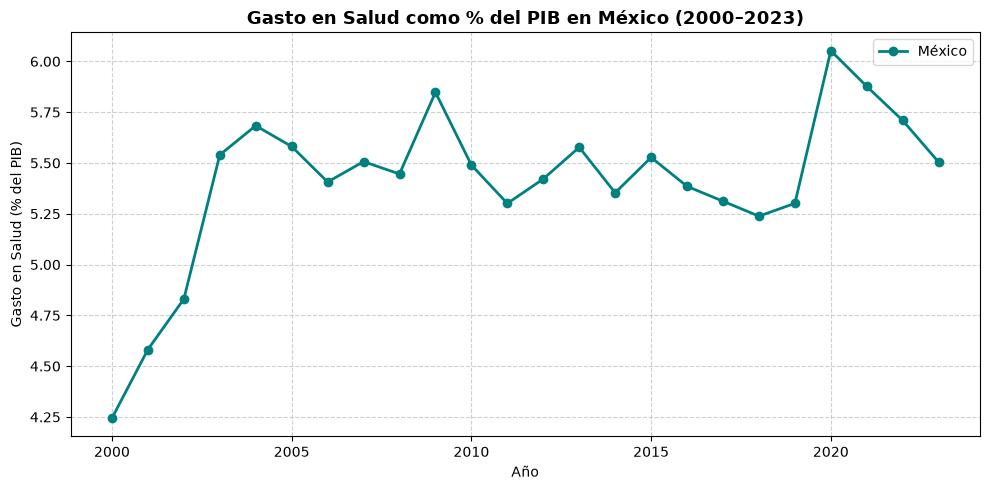

In [ ]:
# Graficar evolución del gasto en salud en México
plt.figure(figsize=(10, 5))
plt.plot(mexico['Anio'], mexico['Gasto_Salud_Pct_PIB'], marker='o', color='teal', linewidth=2, label='México')
plt.title('Gasto en Salud como % del PIB en México (2000–2023)', fontsize=13, fontweight='bold')
plt.xlabel('Año')
plt.ylabel('Gasto en Salud (% del PIB)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### 5. Comparación Internacional (México vs Japón, EE.UU., Alemania, Colombia)

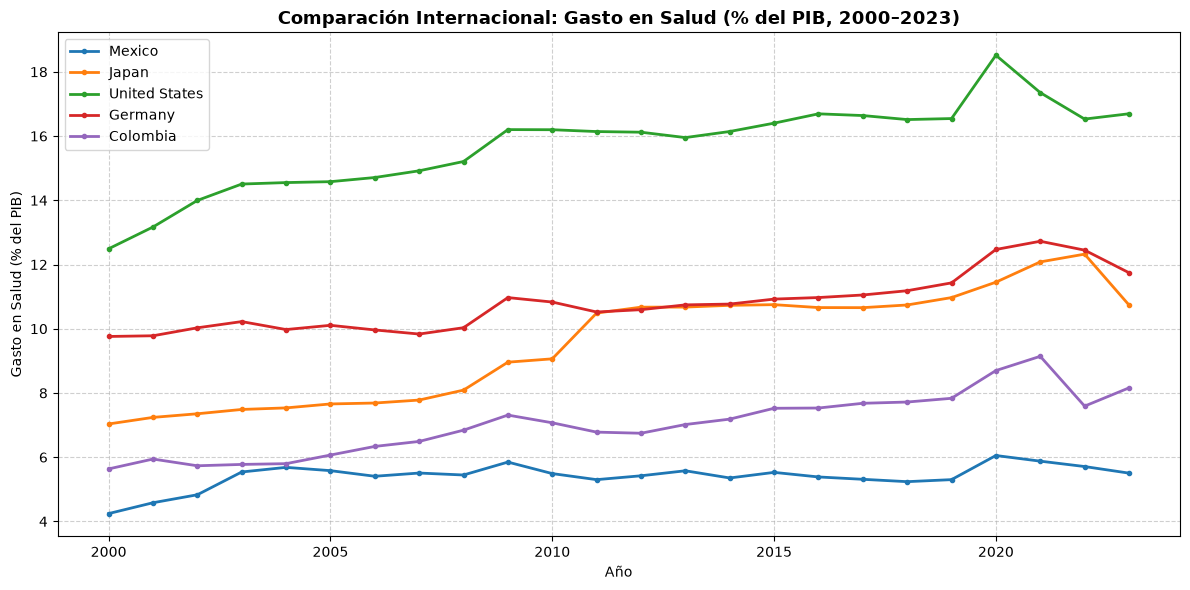

In [ ]:
paises_comp = ['Mexico', 'Japan', 'United States', 'Germany', 'Colombia']
df_comp = df_health[df_health['Pais'].isin(paises_comp)]

plt.figure(figsize=(12, 6))
for pais in paises_comp:
    sub = df_comp[df_comp['Pais'] == pais]
    plt.plot(sub['Anio'], sub['Gasto_Salud_Pct_PIB'], marker='.', label=pais, linewidth=2)

plt.title('Comparación Internacional: Gasto en Salud (% del PIB, 2000–2023)', fontsize=13, fontweight='bold')
plt.xlabel('Año')
plt.ylabel('Gasto en Salud (% del PIB)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### 6. Top 10 Países con Mayor Gasto en Salud (% PIB) en 2021/2022

In [ ]:
# Año 2021 (año con cobertura global completa)
top_salud_2021 = (
    df_health[(df_health['Anio'] == 2021) & (df_health['Codigo'].notnull())]
    .sort_values(by='Gasto_Salud_Pct_PIB', ascending=False)
    .head(10)
)
top_salud_2021[['Pais', 'Codigo', 'Gasto_Salud_Pct_PIB']]

,Pais,Codigo,Gasto_Salud_Pct_PIB
19,Afghanistan,AFG,21.508444
4423,Tuvalu,TUV,18.574112
4541,United States,USA,17.352077
3157,Niue,NIU,15.082194
3277,Palau,PLW,14.552760
1099,Cuba,CUB,13.787466
2437,Liberia,LBR,13.271760
1696,Germany,DEU,12.724033
2688,Marshall Islands,MHL,12.492571
787,Canada,CAN,12.381066
